# **I- Data Preparation and Visualisation**

In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print('GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print('CPU')

GPU: Tesla T4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from PIL import Image
import cv2
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path= glob.glob('/content/drive/MyDrive/B. Disease Grading/*')
path = path[2:]
path

['/content/drive/MyDrive/B. Disease Grading/2. Groundtruths',
 '/content/drive/MyDrive/B. Disease Grading/1. Original Images']

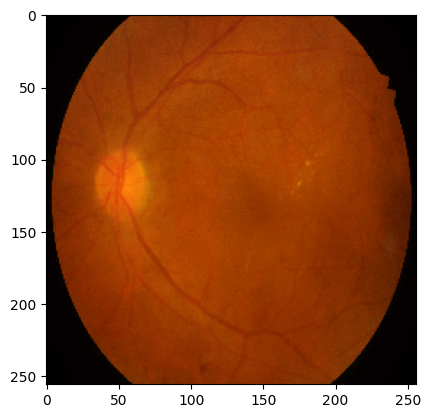

In [ ]:
#import train and test images
Train, Test = [],[]

image_names = sorted([f for f in os.listdir(glob.glob(path[1]+'/*')[1]) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))])
for image_name in image_names:
    image_path = os.path.join(glob.glob(path[1]+'/*')[1], image_name)
    img = cv2.imread(image_path)

    # Get the dimensions of the image
    height, width, channels = img.shape

    # Define the region of interest (ROI)
    x1 = 220   # crop  pixels from the left
    x2 = width - 560  # crop  pixels from the right
    y1 = 0
    y2 = height
    cropped_img = img[y1:y2, x1:x2]

    Train.append(cv2.resize(cropped_img,(256,256)))


plt.imshow(cv2.cvtColor(Train[50], cv2.COLOR_BGR2RGB))

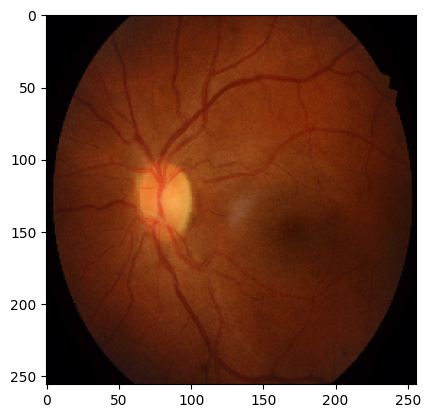

In [ ]:
image_names = sorted([f for f in os.listdir(glob.glob(path[1]+'/*')[0]) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))])
for image_name in image_names:
    image_path = os.path.join(glob.glob(path[1]+'/*')[0], image_name)
    img = cv2.imread(image_path)

    # Get the dimensions of the image
    height, width, channels = img.shape

    # Define the region of interest (ROI)
    x1 = 220   # crop  pixels from the left
    x2 = width - 560  # crop  pixels from the right
    y1 = 0
    y2 = height
    cropped_img = img[y1:y2, x1:x2]

    Test.append(cv2.resize(cropped_img,(256,256)))

plt.imshow(cv2.cvtColor(Test[70], cv2.COLOR_BGR2RGB))

In [ ]:
print("trainingset contains:",len(Train),"and the testset contains ",len(Test))

trainingset contains: 413 and the testset contains  103


In [ ]:
Label_train = pd.read_csv(path[0]+'/a. IDRiD_Disease Grading_Training Labels.csv')
Label_train = Label_train.iloc[:,[1]]
Label_train

,Retinopathy grade
0,3
1,3
2,2
3,3
4,4
...,...
408,2
409,2
410,2
411,2


In [ ]:
count_df = Label_train.groupby(['Retinopathy grade']).size().reset_index(name='Count')
count_df

,Retinopathy grade,Count
0,0,134
1,1,20
2,2,136
3,3,74
4,4,49


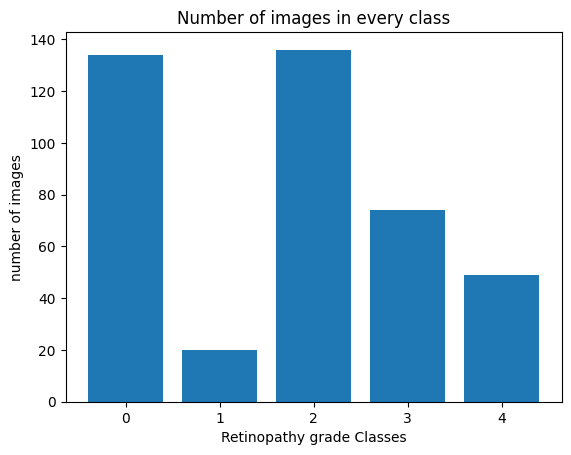

In [ ]:
#x cordinates
x =np.array(count_df['Retinopathy grade'])

#y cordinates
y = np.array(count_df['Count'])

# labels for bars
tick_label = x

# plotting a bar chart
plt.bar(x, y, tick_label = tick_label,
        width = 0.8)#, color = ['red', 'green'])

# naming the x-axis
plt.xlabel('Retinopathy grade Classes')
# naming the y-axis
plt.ylabel('number of images')
# plot title
plt.title('Number of images in every class')

#plt.savefig('/content/drive/MyDrive/unbalanceed.png', dpi=300, bbox_inches='tight')
# function to show the plot
plt.show()

In [ ]:
#for class 0: we have 134:  need 13
#for class 1: we have 20 : need 114 (6) add 7 at the end=>
#for class 2: we have 136  need 11
#for class 3: we have 74 : needs 74 =>148
#for class 4: we have 49 : needs 87 (2)=> 147

# **II- Data Augmentation Using Traditional Techniques**

In [ ]:
n0,n1,n2,typ= 0,0,0,0
new_Train2 = Train.copy()
new_Labels2 = Label_train.copy()

for i,img in enumerate (Train):
  if((Label_train.iloc[i,0])==0 and n0<=13):
    flipped = cv2.flip(img, typ)
    if (typ ==0):
      typ =1
    else:
      typ=0

    new_Train2.append(flipped)
    new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]
    n0 +=1
  elif((Label_train.iloc[i,0])==1):
    for j in range (6):
      flipped = cv2.flip(img, typ)
      if (typ ==0):
        typ =1
      else:
        typ=0
      new_Train2.append(flipped)
      new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]
    if (n1<=7):
      flipped = cv2.flip(img, typ)
      if (typ ==0):
        typ =1
      else:
        typ=0
      new_Train2.append(flipped)
      new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]
      n1 += 1

  elif((Label_train.iloc[i,0])==2 and n2<= 11):
      flipped = cv2.flip(img, typ)
      if (typ ==0):
        typ =1
      else:
        typ=0

      new_Train2.append(flipped)
      new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]
      n2 +=1

  elif((Label_train.iloc[i,0])==3):
      flipped = cv2.flip(img, typ)
      if (typ ==0):
        typ =1
      else:
        typ=0

      new_Train2.append(flipped)
      new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]

  elif((Label_train.iloc[i,0])==4 ):
    for j in range (2):
      flipped = cv2.flip(img, typ)
      if (typ ==0):
        typ =1
      else:
        typ=0

      new_Train2.append(flipped)
      new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0])]


#Make data augmentation for all
new_Labels2 = pd.DataFrame(new_Labels2)
new_Labels = new_Labels2.copy()
new_Train = new_Train2.copy()
for i in range (len(new_Train2)):

  img = new_Train2[i].copy()
  brighter_img_1 = cv2.convertScaleAbs(img, alpha=1, beta=20) 
  brighter_img_2 = cv2.convertScaleAbs(img, alpha=1, beta=40)

  new_Train.append(brighter_img_1)
  new_Train.append(brighter_img_2)
  new_Labels.loc[len(new_Labels)] = [(new_Labels2.iloc[i,0])]
  new_Labels.loc[len(new_Labels)] = [(new_Labels2.iloc[i,0])]

In [ ]:
new_result = new_Labels.groupby(['Retinopathy grade']).size().reset_index(name='Count')
print(new_result)

   Retinopathy grade  Count
0                  0    444
1                  1    444
2                  2    444
3                  3    444
4                  4    441


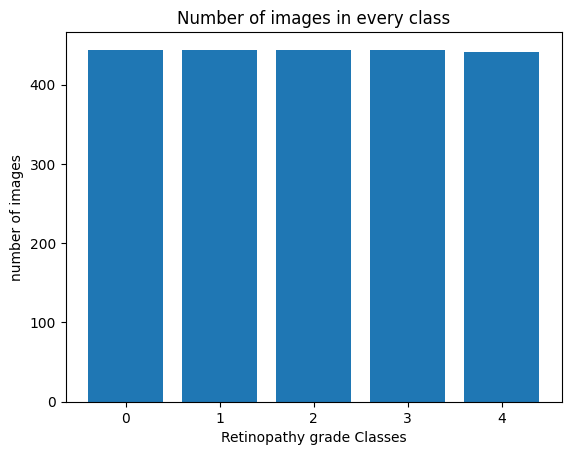

In [ ]:
#x cordinates
x =np.array(new_result['Retinopathy grade'])

#y cordinates
y = np.array(new_result['Count'])

#labels for bars
tick_label = x

#plotting a bar chart
plt.bar(x, y, tick_label = tick_label,
        width = 0.8)

# naming the x-axis
plt.xlabel('Retinopathy grade Classes')
# naming the y-axis
plt.ylabel('number of images')
# plot title
plt.title('Number of images in every class')

# function to show the plot
plt.show()

In [ ]:
##we're going to make the same process with test labels
Label_test = pd.read_csv(path[0]+'/b. IDRiD_Disease Grading_Testing Labels.csv')
Label_test = Label_test.iloc[:,[1]]
Label_test

,Retinopathy grade
0,4
1,4
2,4
3,4
4,4
...,...
98,0
99,2
100,1
101,2


In [ ]:
count_df = Label_test.groupby(['Retinopathy grade']).size().reset_index(name='Count')
count_df

,Retinopathy grade,Count
0,0,34
1,1,5
2,2,32
3,3,19
4,4,13


## *1- Classification Using CNN clasifier*

In [ ]:
#import libraries
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
import torchvision
import torchvision.transforms as transforms


transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

#training image
norm_Train = new_Train.copy()
for i,j in enumerate (new_Train):
  norm_Train[i]= transform(j)

#test image
norm_Test = Test.copy()
for i,j in enumerate (Test):
  norm_Test[i]= transform(j)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]
        return img, label

In [ ]:
# convert the dataframe to a tensor
train_label_tensor  = torch.tensor(new_Labels['Retinopathy grade'].values)
test_label_tensor = torch.tensor(Label_test['Retinopathy grade'].values)

# Number of classes

num_classes = len(torch.unique(train_label_tensor, dim=0))
print("Number of classes:", num_classes)

'''# Get unique values in tensor
unique_labels = torch.unique(train_label_tensor, dim=0)

# Create dictionary to map labels to integer classes
class_dict = {tuple(unique_labels[i].tolist()): i for i in range(len(unique_labels))}

# Encode labels to integer classes
encoded_labels = torch.zeros(train_label_tensor.size(0), dtype=torch.long)
for i in range(train_label_tensor.size(0)):
    encoded_labels[i] = class_dict[tuple(train_label_tensor[i].tolist())]

# Number of classes
num_classes = len(unique_labels)

print("Encoded labels:", encoded_labels)
print("Number of classes:", num_classes)

##encoding the test labels in the same codes
# Encode labels to integer classes
encoded_labels_test = torch.zeros(test_label_tensor.size(0), dtype=torch.long)
for i in range(test_label_tensor.size(0)):
    encoded_labels_test[i] = class_dict[tuple(test_label_tensor[i].tolist())]'''

Number of classes: 5


'# Get unique values in tensor\nunique_labels = torch.unique(train_label_tensor, dim=0)\n\n# Create dictionary to map labels to integer classes\nclass_dict = {tuple(unique_labels[i].tolist()): i for i in range(len(unique_labels))}\n\n# Encode labels to integer classes\nencoded_labels = torch.zeros(train_label_tensor.size(0), dtype=torch.long)\nfor i in range(train_label_tensor.size(0)):\n    encoded_labels[i] = class_dict[tuple(train_label_tensor[i].tolist())]\n\n# Number of classes\nnum_classes = len(unique_labels)\n\nprint("Encoded labels:", encoded_labels)\nprint("Number of classes:", num_classes)\n\n##encoding the test labels in the same codes\n# Encode labels to integer classes\nencoded_labels_test = torch.zeros(test_label_tensor.size(0), dtype=torch.long)\nfor i in range(test_label_tensor.size(0)):\n    encoded_labels_test[i] = class_dict[tuple(test_label_tensor[i].tolist())]'

In [ ]:
# Define the CNN architecture
#so it will be inisilized with the same weightes always
torch.manual_seed(0)

class CNN_Classifier(nn.Module):
    def __init__(self,num_classes): #in_channels = 3, num_class =3):
      super (CNN_Classifier, self).__init__()

      self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size= 2 , stride=1 , padding=1)
      self.bn1 = nn.BatchNorm2d(16)
      self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

      self.conv2 = nn.Conv2d(in_channels=16, out_channels=32,kernel_size= 3, stride=1, padding=1)
      self.bn2 = nn.BatchNorm2d(32)
      self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

      self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
      self.bn3 = nn.BatchNorm2d(64)
      self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

      self.fc1 = nn.Linear(in_features = 64 * 32 * 32, out_features=250)
      self.dropout1 = nn.Dropout(p=0.3)

      self.fc2 = nn.Linear(in_features = 250, out_features = 100)
      self.dropout2 = nn.Dropout(p=0.2)

      self.fc3 = nn.Linear(in_features = 100, out_features = 50)
      self.dropout3 = nn.Dropout(p=0.1)

      self.fc4 = nn.Linear(in_features = 50, out_features = num_classes)


    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64 * 32 * 32)

        x = self.dropout1(torch.relu(self.fc1(x)))
        x = self.dropout2(torch.relu(self.fc2(x)))
        x = self.dropout3(torch.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

In [ ]:
# Define the loss function and optimizer
model_for_traditional = CNN_Classifier(num_classes=5)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_for_traditional.parameters(), lr=0.001)

if torch.cuda.is_available():
    model_for_traditional = model_for_traditional.cuda()
    criterion = criterion.cuda()

In [ ]:
print(model_for_traditional)

CNN_Classifier(
  (conv1): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65536, out_features=250, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=250, out_features=100, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear

In [ ]:
# check if GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

dataset = MyDataset(norm_Train, train_label_tensor)
dataloader = DataLoader(dataset, batch_size=25, shuffle=True)

dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)

epoc, train_acc, tes_acc, train_los, tes_los = [], [], [], [], []

# training loop
for epoch in range(55):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, data in enumerate(dataloader, 0):
        # get inputs and labels from the data loader
        inputs, labels = data

          # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        outputs = model_for_traditional(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # print statistics
        running_loss += loss.item()
        if i % 25 == 24:    # print every 50 mini-batches
            print('[Epoch %d, Batch %5d] loss: %.3f, accuracy: %.3f' % (epoch + 1, i + 1, running_loss / 25, correct / total))#print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 50))

            model_for_traditional.eval()
            loss = 0
            with torch.no_grad():
                y_true = []
                y_pred = []
                for inputs, labels in test_loader:
                    # converting the data into GPU format
                    if torch.cuda.is_available():
                      inputs = inputs.cuda()
                      labels = labels.cuda()

                    # make predictions
                    outputs = model_for_traditional(inputs)
                    _, predicted = torch.max(outputs.data, 1)

                    # collect predictions and labels
                    y_true += labels.tolist()
                    y_pred += predicted.tolist()

                    loss += criterion(outputs, labels).item()

            # calculate accuracy
            accuracy = accuracy_score(y_true, y_pred)

            # Compute the classification report
            target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']

            #compute the loss
            loss /= len(test_loader)

            print("Test Accuracy: {:.2f}%".format(accuracy * 100))
            print("the test loss=",loss)
            tes_acc.append(accuracy)
            tes_los.append(loss)

            epoc.append(epoch + (i / 100))
            train_acc.append(correct / total)
            train_los.append(running_loss / 25)



            model_for_traditional.train()
            running_loss = 0.0
            correct = 0
            total = 0


print('Finished Training')

[Epoch 1, Batch    25] loss: 2.287, accuracy: 0.214
Test Accuracy: 11.65%
the test loss= 1.653377628326416
[Epoch 1, Batch    50] loss: 1.697, accuracy: 0.227
Test Accuracy: 23.30%
the test loss= 1.5833134174346923
[Epoch 1, Batch    75] loss: 1.575, accuracy: 0.278
Test Accuracy: 18.45%
the test loss= 1.6682154893875123
[Epoch 2, Batch    25] loss: 1.549, accuracy: 0.306
Test Accuracy: 18.45%
the test loss= 1.6171546936035157
[Epoch 2, Batch    50] loss: 1.577, accuracy: 0.275
Test Accuracy: 19.42%
the test loss= 1.5096709728240967
[Epoch 2, Batch    75] loss: 1.528, accuracy: 0.320
Test Accuracy: 32.04%
the test loss= 1.5792233228683472
[Epoch 3, Batch    25] loss: 1.525, accuracy: 0.309
Test Accuracy: 33.01%
the test loss= 1.5754182815551758
[Epoch 3, Batch    50] loss: 1.484, accuracy: 0.331
Test Accuracy: 28.16%
the test loss= 1.5609033584594727
[Epoch 3, Batch    75] loss: 1.483, accuracy: 0.323
Test Accuracy: 23.30%
the test loss= 1.5002580404281616
[Epoch 4, Batch    25] loss: 

In [ ]:
# define your dataset and data loader
dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Switch model to evaluation mode
model_for_traditional.eval()

loss = 0
with torch.no_grad():
    y_true = []
    y_pred = []
    for inputs, labels in test_loader:
        # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # make predictions
        outputs = model_for_traditional(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # collect predictions and labels
        y_true += labels.tolist()
        y_pred += predicted.tolist()

        loss += criterion(outputs, labels).item()

# calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute the classification report
target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']
cr = classification_report(y_true, y_pred, target_names=target_names)

#compute the loss
loss /= len(test_loader)

print("Classification report:\n",cr)
print("The Confusion matrix:\n",cm)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("the loss=",loss)


Classification report:
               precision    recall  f1-score   support

     class 0       0.50      0.41      0.45        34
     class 1       0.00      0.00      0.00         5
     class 2       0.37      0.56      0.44        32
     class 3       0.47      0.42      0.44        19
     class 4       0.00      0.00      0.00        13

    accuracy                           0.39       103
   macro avg       0.27      0.28      0.27       103
weighted avg       0.37      0.39      0.37       103

The Confusion matrix:
 [[14  1 18  0  1]
 [ 2  0  2  1  0]
 [ 5  2 18  5  2]
 [ 3  0  5  8  3]
 [ 4  0  6  3  0]]
Accuracy: 38.83%
the loss= 3.1609820425510406


In [ ]:
model_path = '/content/drive/MyDrive/trad_model.pt'
torch.save(model_for_traditional.state_dict(), model_path)

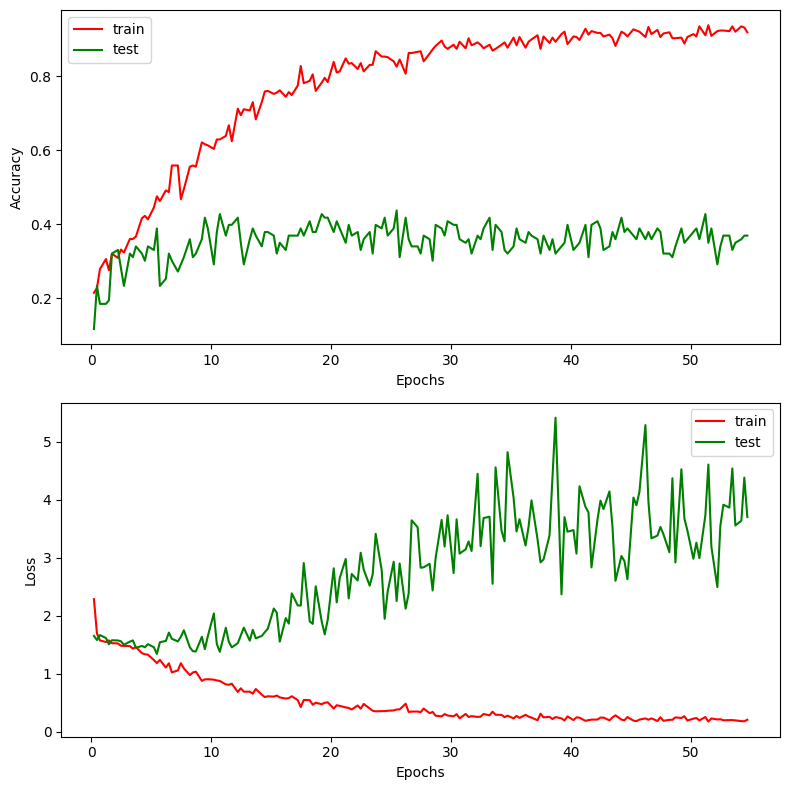

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and set its size to 8 by 8 inches
fig = plt.figure(figsize=(8, 8))

# Create the first subplot
ax1 = fig.add_subplot(211)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.plot(epoc,train_acc, color='red',label='train')  # Replace x1 and y1 with your data
ax1.plot(epoc,tes_acc, color='green',label='test')
plt.legend()

# Create the second subplot
ax2 = fig.add_subplot(212)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.plot(epoc,train_los, color='red',label='train')  # Replace x2 and y2 with your data
ax2.plot(epoc,tes_los, color='green',label='test')
plt.legend()

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
#plt.legend()
plt.show()

The confusion matrix:
 [[12  1 20  1  0]
 [ 2  0  1  0  2]
 [ 6  1 16  3  6]
 [ 3  1  7  8  0]
 [ 1  0  8  3  1]]
Accuracy: 35.92%

## *2- Classification Using Resnet clasifier*

In [ ]:
import torch.nn.init as init

# Load Resnet model
res_trad = torchvision.models.resnet50(pretrained=True)

# Freeze all parameters except the last layer
for param in res_trad.parameters():
    param.requires_grad = False


# Replace the last two fully connected layer of ResNet with a new layers
res_trad.fc = nn.Sequential(
    nn.Linear(res_trad.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 5)  
)

# Initialize the weights of the additional layers using Xavier uniform initialization
for module in res_trad.fc.modules():
    if isinstance(module, nn.Linear):
        init.xavier_normal_ (module.weight)

# Optionally, initialize the bias terms to zero
for module in res_trad.fc.modules():
    if isinstance(module, nn.Linear) and module.bias is not None:
        init.zeros_(module.bias)



# Define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(res_trad.parameters())

if torch.cuda.is_available():
    res_trad = res_trad.cuda()
    criterion = criterion.cuda()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# define your dataset and data loader
dataset = MyDataset(norm_Train, train_label_tensor)
dataloader = DataLoader(dataset, batch_size=25, shuffle=True)

dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)

epoc, train_acc, tes_acc, train_los, tes_los = [], [], [], [], []

# training loop
for epoch in range(25):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, data in enumerate(dataloader, 0):
        # get inputs and labels from the data loader
        inputs, labels = data

          # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        outputs = res_trad(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # print statistics
        running_loss += loss.item()
        if i % 25 == 24:    # print every 50 mini-batches
            print('[Epoch %d, Batch %5d] loss: %.3f, accuracy: %.3f' % (epoch + 1, i + 1, running_loss / 25, correct / total))#print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 50))

            res_trad.eval()
            loss = 0
            with torch.no_grad():
                y_true = []
                y_pred = []
                for inputs, labels in test_loader:
                    # converting the data into GPU format
                    if torch.cuda.is_available():
                      inputs = inputs.cuda()
                      labels = labels.cuda()

                    # make predictions
                    outputs = res_trad(inputs)
                    _, predicted = torch.max(outputs.data, 1)

                    # collect predictions and labels
                    y_true += labels.tolist()
                    y_pred += predicted.tolist()

                    loss += criterion(outputs, labels).item()

            # calculate accuracy
            accuracy = accuracy_score(y_true, y_pred)

            # Compute the classification report
            target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']

            #compute the loss
            loss /= len(test_loader)

            print("Test Accuracy: {:.2f}%".format(accuracy * 100))
            print("the test loss=",loss)

            epoc.append(epoch + (i / 100))
            train_acc.append(correct / total)
            train_los.append(running_loss / 25)

            tes_acc.append(accuracy)
            tes_los.append(loss)

            res_trad.train()
            running_loss = 0.0
            correct = 0
            total = 0


print('Finished Training')


[Epoch 1, Batch    25] loss: 2.060, accuracy: 0.251
Test Accuracy: 28.16%
the test loss= 1.4209115743637084
[Epoch 1, Batch    50] loss: 1.285, accuracy: 0.445
Test Accuracy: 33.01%
the test loss= 1.3856550693511962
[Epoch 1, Batch    75] loss: 1.130, accuracy: 0.533
Test Accuracy: 33.01%
the test loss= 1.6592901229858399
[Epoch 2, Batch    25] loss: 1.021, accuracy: 0.584
Test Accuracy: 37.86%
the test loss= 1.2255305767059326
[Epoch 2, Batch    50] loss: 0.952, accuracy: 0.605
Test Accuracy: 43.69%
the test loss= 1.3129389405250549
[Epoch 2, Batch    75] loss: 0.939, accuracy: 0.618
Test Accuracy: 31.07%
the test loss= 1.8398910284042358
[Epoch 3, Batch    25] loss: 0.909, accuracy: 0.675
Test Accuracy: 43.69%
the test loss= 1.3636061429977417
[Epoch 3, Batch    50] loss: 0.922, accuracy: 0.619
Test Accuracy: 50.49%
the test loss= 1.314728593826294
[Epoch 3, Batch    75] loss: 0.806, accuracy: 0.690
Test Accuracy: 49.51%
the test loss= 1.219390320777893
[Epoch 4, Batch    25] loss: 0

In [ ]:
# define your dataset and data loader
dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Switch model to evaluation mode
res_trad.eval()

loss = 0
with torch.no_grad():
    y_true = []
    y_pred = []
    for inputs, labels in test_loader:
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # make predictions
        outputs = res_trad(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # collect predictions and labels
        y_true += labels.tolist()
        y_pred += predicted.tolist()

        loss += criterion(outputs, labels).item()

# calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute the classification report
target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']
cr = classification_report(y_true, y_pred, target_names=target_names)

#compute the loss
loss /= len(test_loader)

print("Classification report:\n",cr)
print("The Confusion matrix:\n",cm)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("the loss=",loss)


Classification report:
               precision    recall  f1-score   support

     class 0       0.46      0.79      0.58        34
     class 1       0.10      0.20      0.13         5
     class 2       0.67      0.19      0.29        32
     class 3       0.71      0.26      0.38        19
     class 4       0.39      0.54      0.45        13

    accuracy                           0.45       103
   macro avg       0.47      0.40      0.37       103
weighted avg       0.54      0.45      0.42       103

The Confusion matrix:
 [[27  6  0  0  1]
 [ 4  1  0  0  0]
 [17  2  6  2  5]
 [ 6  1  2  5  5]
 [ 5  0  1  0  7]]
Accuracy: 44.66%
the loss= 2.490925431251526


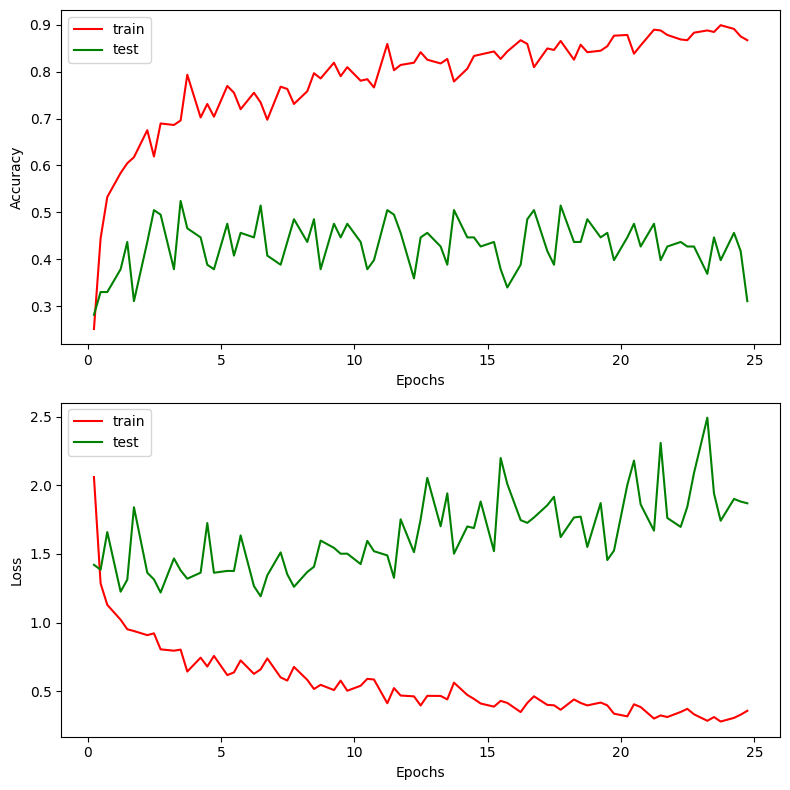

In [ ]:
import matplotlib.pyplot as plt
# Create a figure and set its size to 8 by 8 inches
fig = plt.figure(figsize=(8, 8))

# Create the first subplot
ax1 = fig.add_subplot(211)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.plot(epoc,train_acc, color='red',label='train')  # Replace x1 and y1 with your data
ax1.plot(epoc,tes_acc, color='green',label='test')
plt.legend()

# Create the second subplot
ax2 = fig.add_subplot(212)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.plot(epoc,train_los, color='red',label='train')  # Replace x2 and y2 with your data
ax2.plot(epoc,tes_los, color='green',label='test')
plt.legend()

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
#plt.legend()
plt.show()

# **III- Data augmentation using Diffusion Model (DALLE)**

In [ ]:
# check if GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [ ]:
dalle_train, dalle_label = [], []
path= glob.glob('/content/drive/MyDrive/Augmented_dalle/*')

for j in (path):
  image_names = sorted([f for f in os.listdir(j) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))])
  for image_name in image_names:

      image_path = os.path.join(j, image_name)
      img = cv2.imread(image_path)

      dalle_train.append(img)
      dalle_label.append(int(j[47]))

dalle_label = pd.DataFrame(dalle_label)
dalle_label.columns = ['Retinopathy grade']



In [ ]:
from sklearn.utils import shuffle
dalle_train, dalle_label = shuffle(dalle_train, dalle_label, random_state=1)

In [ ]:
count_df = dalle_label.groupby(['Retinopathy grade']).size().reset_index(name='Count')
print(count_df)

   Retinopathy grade  Count
0                  0    444
1                  1    444
2                  2    444
3                  3    444
4                  4    441


In [ ]:
# Apply the transformation (normlize pixels) to the train image
norm_dalle_Train = dalle_train.copy()
for i,j in enumerate (dalle_train):
  norm_dalle_Train[i]= transform(j)


# convert the dataframe to a tensor
dalle_label_tensor  = torch.tensor(dalle_label['Retinopathy grade'].values)


## *1- Classification Using CNN clasifier*

In [ ]:
# Define the CNN architecture
#so it will be inisilized with the same weightes always
torch.manual_seed(0)

class CNN_Classifier(nn.Module):
    def __init__(self,num_classes): 
      super (CNN_Classifier, self).__init__()

      self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size= 2 , stride=1 , padding=1)
      self.bn1 = nn.BatchNorm2d(16)
      self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

      self.conv2 = nn.Conv2d(in_channels=16, out_channels=32,kernel_size= 3, stride=1, padding=1)
      self.bn2 = nn.BatchNorm2d(32)
      self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

      self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
      self.bn3 = nn.BatchNorm2d(64)
      self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

      self.fc1 = nn.Linear(in_features = 64 * 32 * 32, out_features=250)
      self.dropout1 = nn.Dropout(p=0.3)

      self.fc2 = nn.Linear(in_features = 250, out_features = 100)
      self.dropout2 = nn.Dropout(p=0.2)

      self.fc3 = nn.Linear(in_features = 100, out_features = 50)
      self.dropout3 = nn.Dropout(p=0.1)

      self.fc4 = nn.Linear(in_features = 50, out_features = num_classes)


    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64 * 32 * 32)

        x = self.dropout1(torch.relu(self.fc1(x)))
        x = self.dropout2(torch.relu(self.fc2(x)))
        x = self.dropout3(torch.relu(self.fc3(x)))
        x = self.fc4(x)
        return x



In [ ]:
model_for_Dalle = CNN_Classifier(num_classes=5)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_for_Dalle.parameters(), lr=0.001)

if torch.cuda.is_available():
    model_for_Dalle = model_for_Dalle.cuda()
    criterion = criterion.cuda()

In [ ]:
print(model_for_Dalle)

CNN_Classifier(
  (conv1): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (skip_connection): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=262144, out_features=250, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=250, out_features=100

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# define your dataset and data loader
dataset = MyDataset(norm_dalle_Train, dalle_label_tensor)
dataloader = DataLoader(dataset, batch_size=25, shuffle=True)

dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)

epoc, train_acc, tes_acc, train_los, tes_los = [], [], [], [], []

# training loop
for epoch in range(55):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, data in enumerate(dataloader, 0):
        # get inputs and labels from the data loader
        inputs, labels = data

          # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        outputs = model_for_Dalle(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # print statistics
        running_loss += loss.item()
        if i % 25 == 24:    # print every 25 mini-batches
            print('[Epoch %d, Batch %5d] loss: %.3f, accuracy: %.3f' % (epoch + 1, i + 1, running_loss / 25, correct / total))#print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 50))
            epoc.append(epoch + (i / 100))
            train_acc.append(correct / total)
            train_los.append(running_loss / 25)

            model_for_Dalle.eval()
            loss = 0
            with torch.no_grad():
                y_true = []
                y_pred = []
                for inputs, labels in test_loader:
                    # converting the data into GPU format
                    if torch.cuda.is_available():
                      inputs = inputs.cuda()
                      labels = labels.cuda()

                    # make predictions
                    outputs = model_for_Dalle(inputs)
                    _, predicted = torch.max(outputs.data, 1)

                    # collect predictions and labels
                    y_true += labels.tolist()
                    y_pred += predicted.tolist()

                    loss += criterion(outputs, labels).item()

            # calculate accuracy
            accuracy = accuracy_score(y_true, y_pred)

            # Compute the classification report
            target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']

            #compute the loss
            loss /= len(test_loader)

            print("Test Accuracy: {:.2f}%".format(accuracy * 100))
            print("the test loss=",loss)

            tes_acc.append(accuracy)
            tes_los.append(loss)

            model_for_Dalle.train()
            running_loss = 0.0
            correct = 0
            total = 0


print('Finished Training')


[Epoch 1, Batch    25] loss: 1.977, accuracy: 0.235
Test Accuracy: 22.33%
the test loss= 1.7593063354492187
[Epoch 1, Batch    50] loss: 1.751, accuracy: 0.221
Test Accuracy: 36.89%
the test loss= 1.5276855945587158
[Epoch 1, Batch    75] loss: 1.600, accuracy: 0.291
Test Accuracy: 37.86%
the test loss= 1.5272857189178466
[Epoch 2, Batch    25] loss: 1.578, accuracy: 0.285
Test Accuracy: 31.07%
the test loss= 1.509601926803589
[Epoch 2, Batch    50] loss: 1.556, accuracy: 0.298
Test Accuracy: 39.81%
the test loss= 1.4786450862884521
[Epoch 2, Batch    75] loss: 1.534, accuracy: 0.333
Test Accuracy: 27.18%
the test loss= 1.620477032661438
[Epoch 3, Batch    25] loss: 1.521, accuracy: 0.291
Test Accuracy: 38.83%
the test loss= 1.5639275074005128
[Epoch 3, Batch    50] loss: 1.541, accuracy: 0.338
Test Accuracy: 32.04%
the test loss= 1.473602795600891
[Epoch 3, Batch    75] loss: 1.503, accuracy: 0.314
Test Accuracy: 36.89%
the test loss= 1.5264363765716553
[Epoch 4, Batch    25] loss: 1.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# define your test dataset and data loader
dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)

# Switch model to evaluation mode
model_for_Dalle.eval()

with torch.no_grad():
    y_true = []
    y_pred = []
    loss=0
    for inputs, labels in test_loader:
        # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # make predictions
        outputs = model_for_Dalle(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # collect predictions and labels
        y_true += labels.tolist()
        y_pred += predicted.tolist()

        loss += criterion(outputs, labels).item()

# calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute the classification report
target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']
cr = classification_report(y_true, y_pred, target_names=target_names)

loss /= len(test_loader)

print("Classification report:\n",cr)
print("The Confusion matrix:\n",cm)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("the loss =",loss)

Classification report:
               precision    recall  f1-score   support

     class 0       0.62      0.59      0.61        34
     class 1       0.00      0.00      0.00         5
     class 2       0.44      0.62      0.52        32
     class 3       0.38      0.32      0.34        19
     class 4       0.00      0.00      0.00        13

    accuracy                           0.45       103
   macro avg       0.29      0.31      0.29       103
weighted avg       0.41      0.45      0.42       103

The Confusion matrix:
 [[20  3  8  3  0]
 [ 1  0  3  0  1]
 [ 3  0 20  5  4]
 [ 4  1  7  6  1]
 [ 4  0  7  2  0]]
Accuracy: 44.66%
the loss = 2.451299214363098


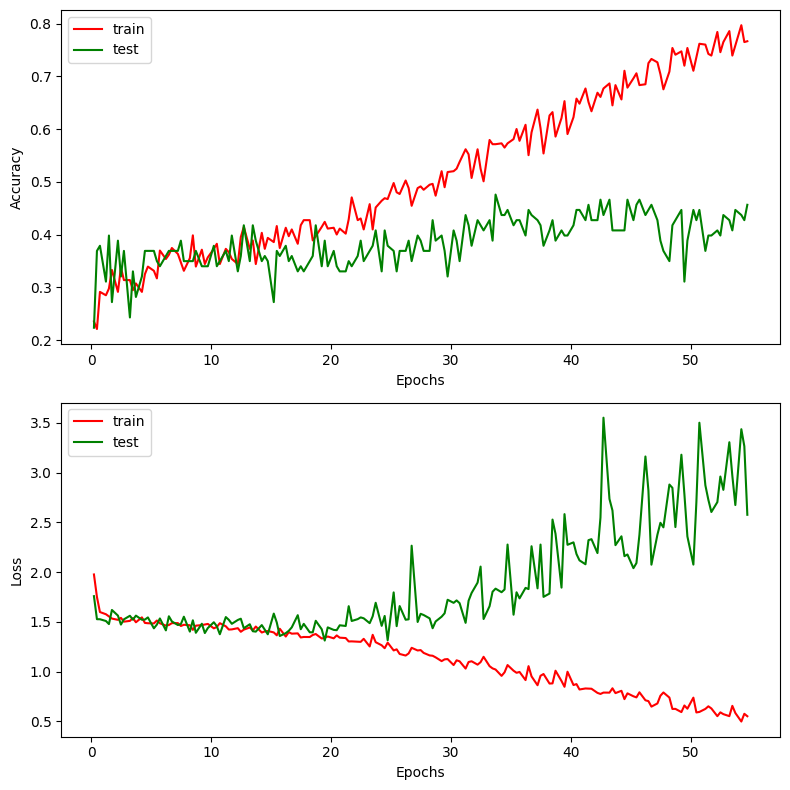

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))

# Create the first subplot
ax1 = fig.add_subplot(211)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.plot(epoc,train_acc, color='red',label='train')  # Replace x1 and y1 with your data
ax1.plot(epoc,tes_acc, color='green',label='test')
plt.legend()

# Create the second subplot
ax2 = fig.add_subplot(212)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.plot(epoc,train_los, color='red',label='train')  # Replace x2 and y2 with your data
ax2.plot(epoc,tes_los, color='green',label='test')
plt.legend()

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot

plt.show()

In [ ]:
model_path = '/content/drive/MyDrive/dalle_model.pt'
torch.save(model_for_Dalle.state_dict(), model_path)

## *2- Classification Using Resnet clasifier*

In [ ]:
import torch.nn.init as init
# Load Resnet model
res_dalle = torchvision.models.resnet50(pretrained=True)

# Freeze all parameters except the last layer
#for param in res_dalle.parameters():
#    param.requires_grad = False


# Replace the last two fully connected layer of ResNet with a new layers
res_dalle.fc = nn.Sequential(
    nn.Linear(res_dalle.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 5)  # Assuming `num_classes` is the number of classes in your dataset
)

# Initialize the weights of the additional layers using Xavier uniform initialization
for module in res_dalle.fc.modules():
    if isinstance(module, nn.Linear):
        init.xavier_normal_ (module.weight)

# Optionally, initialize the bias terms to zero
for module in res_dalle.fc.modules():
    if isinstance(module, nn.Linear) and module.bias is not None:
        init.zeros_(module.bias)



# Define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(res_dalle.parameters())

if torch.cuda.is_available():
    res_dalle = res_dalle.cuda()
    criterion = criterion.cuda()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# define your dataset and data loader
train_dataset = MyDataset(norm_dalle_Train, dalle_label_tensor)
dataloader = DataLoader(train_dataset, batch_size=25, shuffle=True)

# Define your test dataset and data loader
test_dataset = MyDataset(norm_Test, test_label_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=25, shuffle=True)

epoc, train_acc, tes_acc, train_los, tes_los = [], [], [], [], []

# training loop
for epoch in range(10):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, data in enumerate(dataloader, 0):
        # get inputs and labels from the data loader
        inputs, labels = data

          # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        outputs = res_dalle(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # print statistics
        running_loss += loss.item()
        if i % 25 == 24:    # print every 50 mini-batches
            print('[Epoch %d, Batch %5d] loss: %.3f, accuracy: %.3f' % (epoch + 1, i + 1, running_loss / 25, correct / total))#print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 50))

            res_dalle.eval()
            loss = 0
            with torch.no_grad():
                y_true = []
                y_pred = []
                for inputs, labels in test_dataloader:
                    # converting the data into GPU format
                    if torch.cuda.is_available():
                      inputs = inputs.cuda()
                      labels = labels.cuda()

                    # make predictions
                    outputs = res_dalle(inputs)
                    _, predicted = torch.max(outputs.data, 1)

                    # collect predictions and labels
                    y_true += labels.tolist()
                    y_pred += predicted.tolist()

                    loss += criterion(outputs, labels).item()

            # calculate accuracy
            accuracy = accuracy_score(y_true, y_pred)

            # Compute the classification report
            target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']

            #compute the loss
            loss /= len(test_dataloader)

            print("Test Accuracy: {:.2f}%".format(accuracy * 100))
            print("the test loss=",loss)

            epoc.append(epoch + (i / 100))
            train_acc.append(correct / total)
            train_los.append(running_loss / 25)

            tes_acc.append(accuracy)
            tes_los.append(loss)

            res_dalle.train()
            running_loss = 0.0
            correct = 0
            total = 0


print('Finished Training')


[Epoch 1, Batch    25] loss: 1.173, accuracy: 0.491
Test Accuracy: 41.75%
the test loss= 1.3489946126937866
[Epoch 1, Batch    50] loss: 1.193, accuracy: 0.464
Test Accuracy: 51.46%
the test loss= 1.2822818040847779
[Epoch 1, Batch    75] loss: 1.214, accuracy: 0.470
Test Accuracy: 46.60%
the test loss= 1.273787546157837
[Epoch 2, Batch    25] loss: 1.140, accuracy: 0.520
Test Accuracy: 47.57%
the test loss= 1.5088252305984498
[Epoch 2, Batch    50] loss: 1.201, accuracy: 0.472
Test Accuracy: 49.51%
the test loss= 1.1520225524902343
[Epoch 2, Batch    75] loss: 1.164, accuracy: 0.491
Test Accuracy: 54.37%
the test loss= 1.2443495988845825
[Epoch 3, Batch    25] loss: 1.150, accuracy: 0.509
Test Accuracy: 46.60%
the test loss= 1.2968860387802124
[Epoch 3, Batch    50] loss: 1.138, accuracy: 0.522
Test Accuracy: 52.43%
the test loss= 1.2327339053153992
[Epoch 3, Batch    75] loss: 1.126, accuracy: 0.515
Test Accuracy: 44.66%
the test loss= 1.334552240371704
[Epoch 4, Batch    25] loss: 1

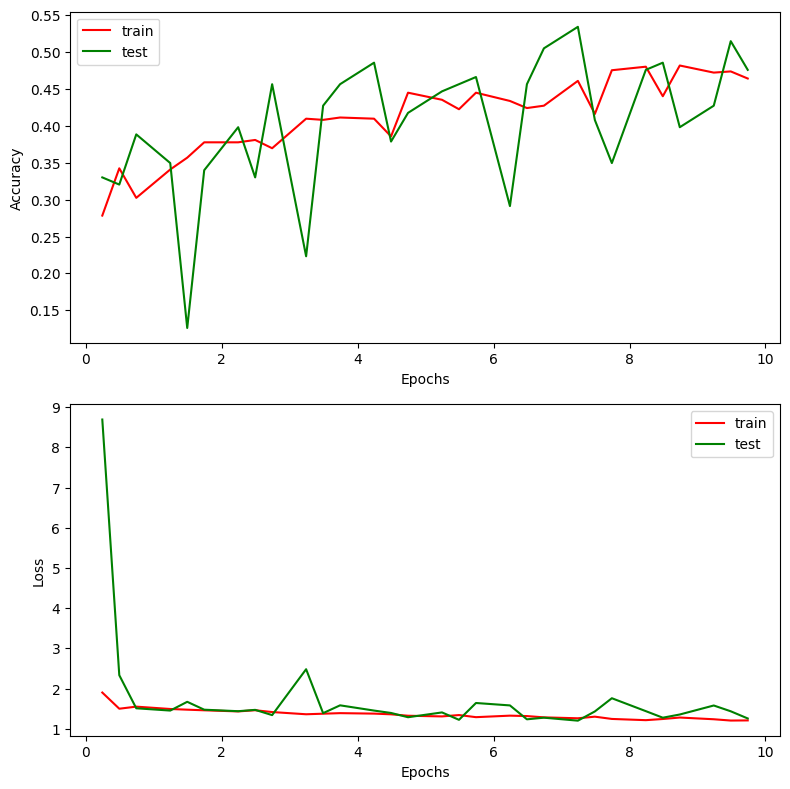

In [ ]:
import matplotlib.pyplot as plt
# Our Cnn for traditional
# Create a figure and set its size to 8 by 8 inches
fig = plt.figure(figsize=(8, 8))

# Create the first subplot
ax1 = fig.add_subplot(211)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.plot(epoc,train_acc, color='red',label='train')  # Replace x1 and y1 with your data
ax1.plot(epoc,tes_acc, color='green',label='test')
plt.legend()
# Create the second subplot
ax2 = fig.add_subplot(212)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.plot(epoc,train_los, color='red',label='train')  # Replace x2 and y2 with your data
ax2.plot(epoc,tes_los, color='green',label='test')
plt.legend()

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
test_label_tensor = torch.tensor(Label_test['Retinopathy grade'].values)
dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)
# Switch model to evaluation mode
res_dalle.eval()

with torch.no_grad():
    y_true = []
    y_pred = []
    loss=0
    for inputs, labels in test_loader:
        # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # make predictions
        outputs = res_dalle(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # collect predictions and labels
        y_true += labels.tolist()
        y_pred += predicted.tolist()

        loss += criterion(outputs, labels).item()

# calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute the classification report
target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']
cr = classification_report(y_true, y_pred, target_names=target_names)

loss /= len(test_loader)

print("Classification report:\n",cr)
print("The Confusion matrix:\n",cm)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("the loss =",loss)

Classification report:
               precision    recall  f1-score   support

     class 0       0.61      0.65      0.63        34
     class 1       0.00      0.00      0.00         5
     class 2       0.44      0.69      0.54        32
     class 3       1.00      0.37      0.54        19
     class 4       0.50      0.31      0.38        13

    accuracy                           0.53       103
   macro avg       0.51      0.40      0.42       103
weighted avg       0.59      0.53      0.52       103

The Confusion matrix:
 [[22  1 11  0  0]
 [ 4  0  1  0  0]
 [ 7  0 22  0  3]
 [ 1  0 10  7  1]
 [ 2  1  6  0  4]]
Accuracy: 53.40%
the loss = 1.3699925899505616


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))

# Create the first subplot
ax1 = fig.add_subplot(211)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.plot(epoc,train_acc, color='red',label='train')  # Replace x1 and y1 with your data
ax1.plot(epoc,tes_acc, color='green',label='test')
plt.legend()
# Create the second subplot
ax2 = fig.add_subplot(212)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.plot(epoc,train_los, color='red',label='train')  # Replace x2 and y2 with your data
ax2.plot(epoc,tes_los, color='green',label='test')
plt.legend()

# Adjust the spacing between subplots
fig.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Assuming `model` is your trained PyTorch model
# and `model_path` is the path where you want to save the model
model_path = '/content/drive/MyDrive/resnet_dalle.pt'
torch.save(vgg_dalle.state_dict(), model_path)

In [ ]:
model_path = '/content/drive/MyDrive/resnet_dalle_acc=53.pt'
torch.save(res_dalle.state_dict(), model_path)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import torch
import torchvision.models as models
model = models.resnet50()
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 5)  # Assuming `num_classes` is the number of classes in your dataset
)  # Replace num_classes with the appropriate number for your task

model_path = '/content/drive/MyDrive/resnet_dalle.pt'  # Path to the saved model
model.load_state_dict(torch.load(model_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
test_label_tensor = torch.tensor(Label_test['Retinopathy grade'].values)
dataset = MyDataset(norm_Test, test_label_tensor)
test_loader = DataLoader(dataset, batch_size=25, shuffle=True)
# Switch model to evaluation mode
model.eval()
if torch.cuda.is_available():
    model = model.cuda()

with torch.no_grad():
    y_true = []
    y_pred = []
    loss=0
    for inputs, labels in test_loader:
        # converting the data into GPU format
        if torch.cuda.is_available():
          inputs = inputs.cuda()
          labels = labels.cuda()

        # make predictions
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # collect predictions and labels
        y_true += labels.tolist()
        y_pred += predicted.tolist()

        loss += criterion(outputs, labels).item()

# calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute the classification report
target_names = ['class 0', 'class 1', 'class 2','class 3','class 4']
cr = classification_report(y_true, y_pred, target_names=target_names)

loss /= len(test_loader)

print("Classification report:\n",cr)
print("The Confusion matrix:\n",cm)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("the loss =",loss)

Classification report:
               precision    recall  f1-score   support

     class 0       0.61      0.74      0.67        34
     class 1       0.00      0.00      0.00         5
     class 2       0.42      0.53      0.47        32
     class 3       0.53      0.47      0.50        19
     class 4       0.60      0.23      0.33        13

    accuracy                           0.52       103
   macro avg       0.43      0.39      0.39       103
weighted avg       0.51      0.52      0.50       103

The Confusion matrix:
 [[25  0  8  1  0]
 [ 4  0  1  0  0]
 [ 9  0 17  4  2]
 [ 1  0  9  9  0]
 [ 2  0  5  3  3]]
Accuracy: 52.43%
the loss = 1.1850794196128844


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
